In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
%matplotlib inline

In [35]:
df=pd.read_excel(r"C:\Users\sanum\Desktop\assignment\assignments data\forecasting\Airlines+Data.xlsx")
df.head()

,Month,Passengers
0,1995-01-01,112
1,1995-02-01,118
2,1995-03-01,132
3,1995-04-01,129
4,1995-05-01,121


In [60]:
air = df.copy()

In [61]:
air.head()

,Month,Passengers
0,1995-01-01,112
1,1995-02-01,118
2,1995-03-01,132
3,1995-04-01,129
4,1995-05-01,121


In [62]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       96 non-null     datetime64[ns]
 1   Passengers  96 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.6 KB


In [63]:
air.describe()

,Month,Passengers
count,96,96.000000
mean,1998-12-16 05:00:00,213.708333
min,1995-01-01 00:00:00,104.000000
25%,1996-12-24 06:00:00,156.000000
50%,1998-12-16 12:00:00,200.000000
75%,2000-12-08 18:00:00,264.750000
max,2002-12-01 00:00:00,413.000000
std,NaN,71.918216


# Lineplot

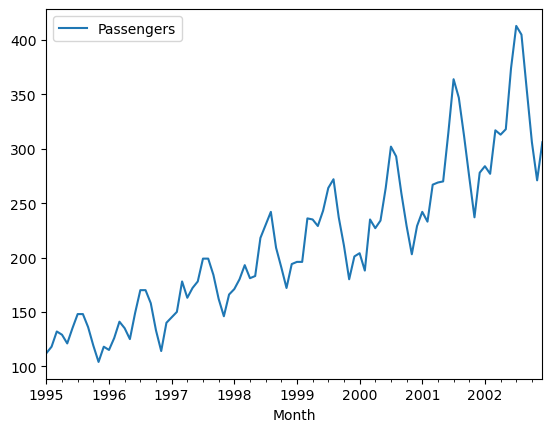

In [64]:
df1=pd.read_excel(r"C:\Users\sanum\Desktop\assignment\assignments data\forecasting\Airlines+Data.xlsx", header=0, index_col=0, parse_dates=True)
df1.plot()
plt.show()

In [65]:
df1.head()

,Passengers
Month,
1995-01-01,112
1995-02-01,118
1995-03-01,132
1995-04-01,129
1995-05-01,121


# Histogram and Density Plot

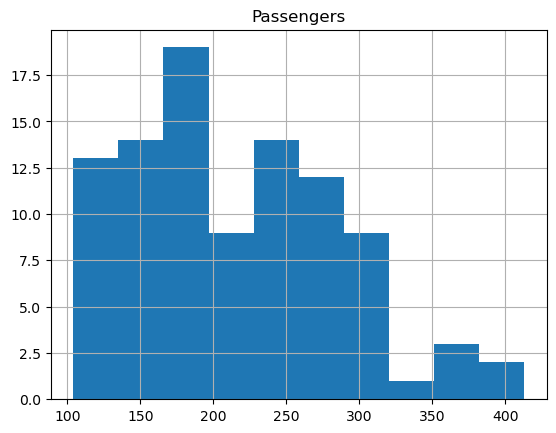

In [66]:
# create a histogram plot
df1.hist()
plt.show()

<Axes: ylabel='Density'>

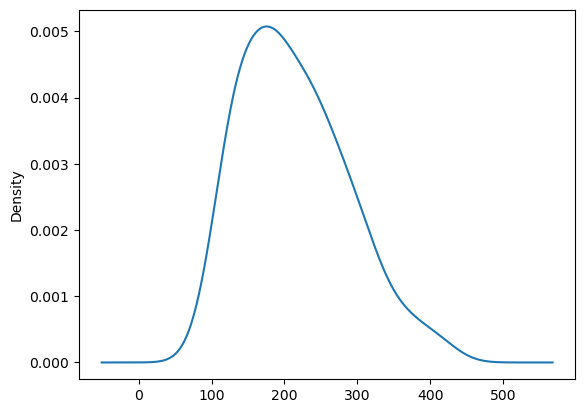

In [67]:
df1.Passengers.plot(kind='kde')

# Square Transformation

In [68]:
upsampled = df1.resample('D').mean()
print(upsampled.head(20))

            Passengers
Month                 
1995-01-01       112.0
1995-01-02         NaN
1995-01-03         NaN
1995-01-04         NaN
1995-01-05         NaN
1995-01-06         NaN
1995-01-07         NaN
1995-01-08         NaN
1995-01-09         NaN
1995-01-10         NaN
1995-01-11         NaN
1995-01-12         NaN
1995-01-13         NaN
1995-01-14         NaN
1995-01-15         NaN
1995-01-16         NaN
1995-01-17         NaN
1995-01-18         NaN
1995-01-19         NaN
1995-01-20         NaN


            Passengers
Month                 
1995-01-01  112.000000
1995-01-02  112.193548
1995-01-03  112.387097
1995-01-04  112.580645
1995-01-05  112.774194
1995-01-06  112.967742
1995-01-07  113.161290
1995-01-08  113.354839
1995-01-09  113.548387
1995-01-10  113.741935
1995-01-11  113.935484
1995-01-12  114.129032
1995-01-13  114.322581
1995-01-14  114.516129
1995-01-15  114.709677
1995-01-16  114.903226
1995-01-17  115.096774
1995-01-18  115.290323
1995-01-19  115.483871
1995-01-20  115.677419
1995-01-21  115.870968
1995-01-22  116.064516
1995-01-23  116.258065
1995-01-24  116.451613
1995-01-25  116.645161
1995-01-26  116.838710
1995-01-27  117.032258
1995-01-28  117.225806
1995-01-29  117.419355
1995-01-30  117.612903
1995-01-31  117.806452
1995-02-01  118.000000


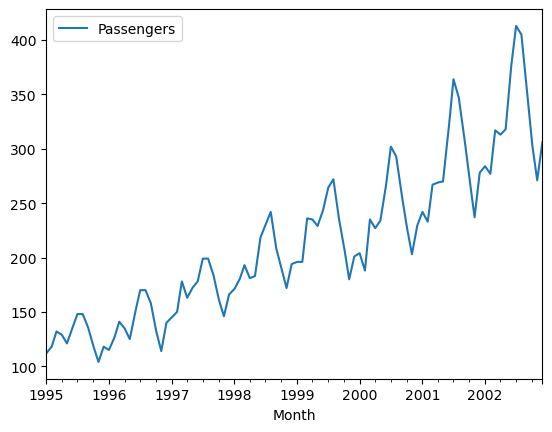

In [69]:
interpolated = upsampled.interpolate(method='linear')
print(interpolated.head(32))
interpolated.plot()
plt.show()

# Before Tranformation

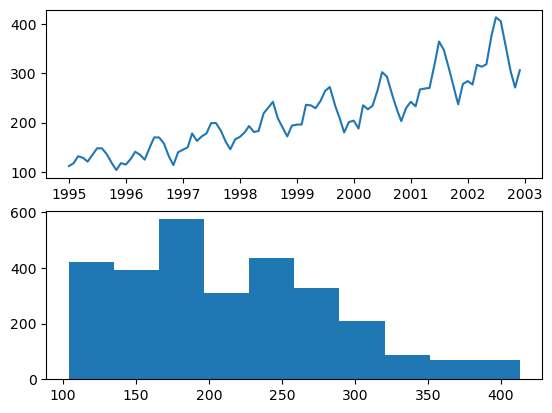

In [70]:
plt.subplot(211)
plt.plot(interpolated)
plt.subplot(212)
plt.hist(interpolated)
plt.show()

In [71]:
interpolated

,Passengers
Month,
1995-01-01,112.000000
1995-01-02,112.193548
1995-01-03,112.387097
1995-01-04,112.580645
1995-01-05,112.774194
...,...
2002-11-27,301.333333
2002-11-28,302.500000
2002-11-29,303.666667


# Square Root Transform

In [75]:
dataframe = pd.DataFrame(interpolated)
dataframe.columns = ['Passengers']
interpolated['Passengers'] = np.sqrt(interpolated['Passengers'])

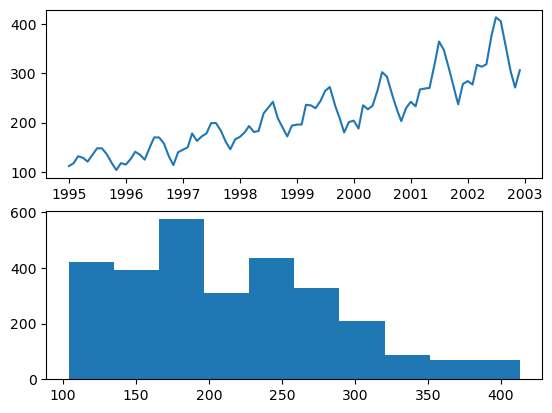

In [76]:
plt.subplot(211)
plt.plot(dataframe['Passengers'])
plt.subplot(212)
plt.hist(dataframe['Passengers'])
plt.show()

In [77]:
interpolated

,Passengers
Month,
1995-01-01,10.583005
1995-01-02,10.592146
1995-01-03,10.601278
1995-01-04,10.610403
1995-01-05,10.619519
...,...
2002-11-27,17.358955
2002-11-28,17.392527
2002-11-29,17.426034


# Log Transform

In [84]:
dataframe=pd.DataFrame(interpolated)
dataframe.columns=['Passengers']
interpolated['Passengers'] = np.log(interpolated['Passengers'])

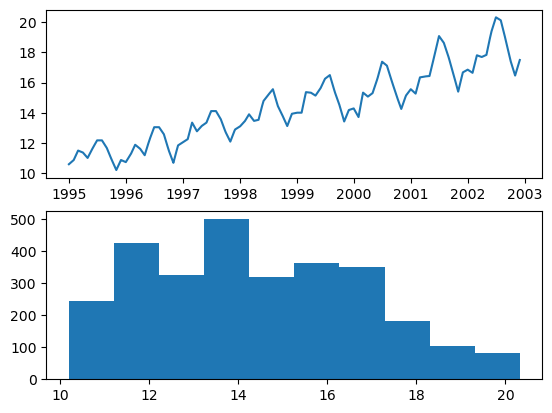

In [85]:
plt.subplot(211)
plt.plot(dataframe['Passengers'])
plt.subplot(212)
plt.hist(dataframe['Passengers'])
plt.show()

In [86]:
interpolated

,Passengers
Month,
1995-01-01,2.359249
1995-01-02,2.360113
1995-01-03,2.360975
1995-01-04,2.361835
1995-01-05,2.362694
...,...
2002-11-27,2.854109
2002-11-28,2.856041
2002-11-29,2.857965


In [87]:
interpolated.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2892 entries, 1995-01-01 to 2002-12-01
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Passengers  2892 non-null   float64
dtypes: float64(1)
memory usage: 45.2 KB


In [89]:
air["Date"]=pd.to_datetime(air.Month, format="%b-%y")
air["Months"]=air.Date.dt.strftime("%b")
air["Year"]=air.Date.dt.strftime("%Y")

<Axes: xlabel='Months', ylabel='Passengers'>

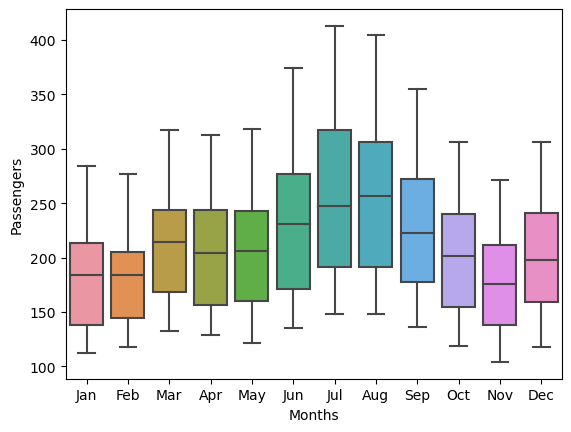

In [91]:
sns.boxplot(x='Months', y='Passengers', data=air)

<Axes: xlabel='Year', ylabel='Passengers'>

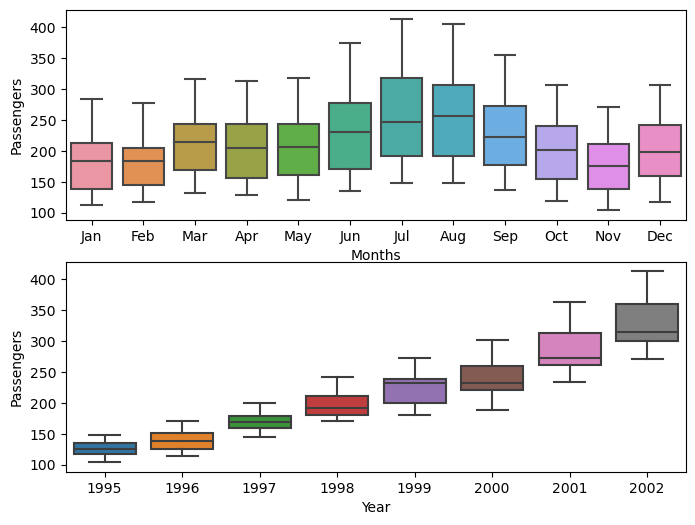

In [93]:
plt.figure(figsize=(8,6))
plt.subplot(211)
sns.boxplot(x='Months', y='Passengers', data=air)
plt.subplot(212)
sns.boxplot(x='Year', y='Passengers', data=air)

In [97]:
Month_Dummies=pd.DataFrame(pd.get_dummies(air['Months']))
air=pd.concat([air, Month_Dummies], axis=1)

In [98]:
len(df1)

96

In [99]:
print("Column Names:", air.columns)

Column Names: Index(['Month', 'Passengers', 'Date', 'Months', 'Year', 'Apr', 'Aug', 'Dec',
       'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep', 'Apr',
       'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct',
       'Sep'],
      dtype='object')


In [101]:
df1["t"]=np.arange(1,97)
df1["t_squared"]=df1["t"]*df1["t"]
df1["Log_Passengers"]=np.log(df1["Passengers"])

In [102]:
df1

,Passengers,t,t_squared,Log_Passengers
Month,,,,
1995-01-01,112,1,1,4.718499
1995-02-01,118,2,4,4.770685
1995-03-01,132,3,9,4.882802
1995-04-01,129,4,16,4.859812
1995-05-01,121,5,25,4.795791
...,...,...,...,...
2002-08-01,405,92,8464,6.003887
2002-09-01,355,93,8649,5.872118
2002-10-01,306,94,8836,5.723585


# Moving Average

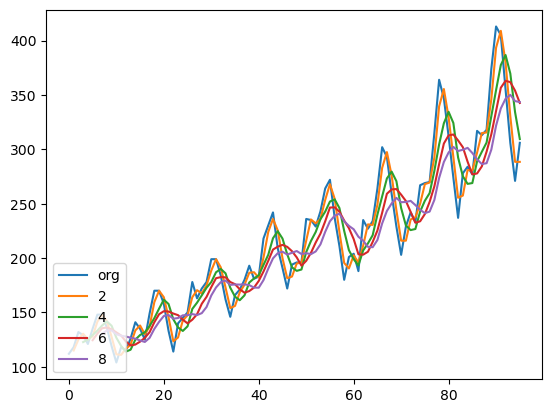

In [105]:
air.Passengers.plot(label="org")
for i in  range(2,10,2):
    air["Passengers"].rolling(i).mean().plot(label=str(i))
plt.legend(loc=3)

<Axes: >

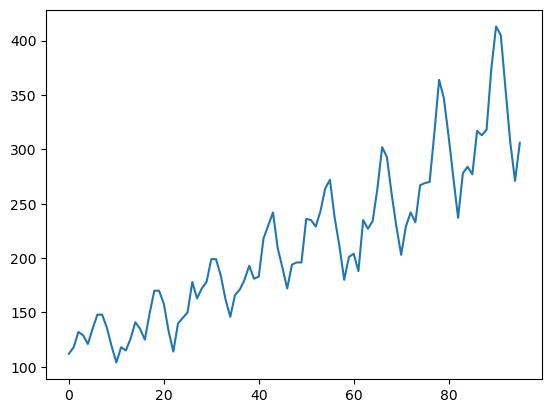

In [106]:
air.Passengers.plot()

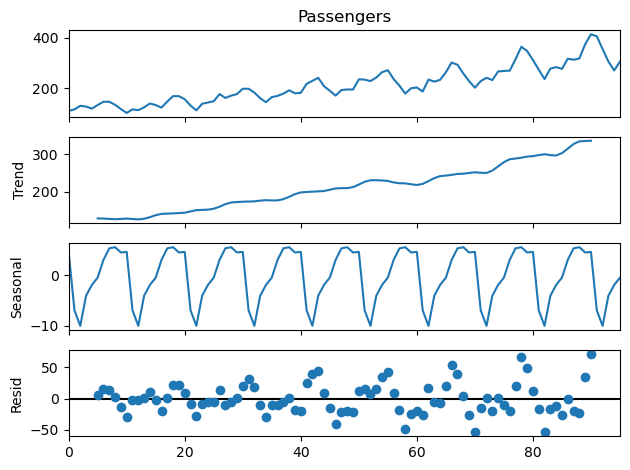

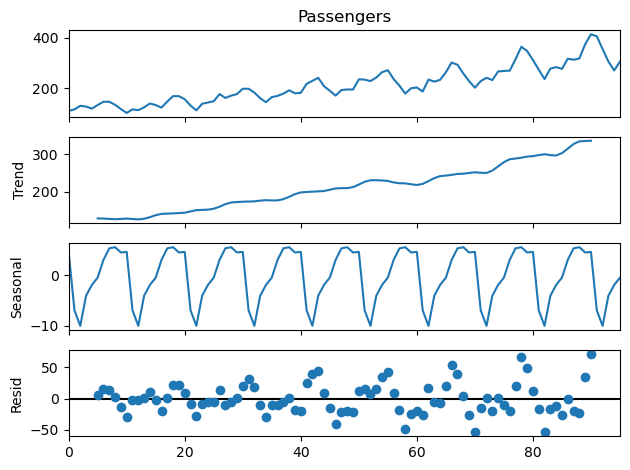

In [108]:
seasonal_ts_add=seasonal_decompose(air["Passengers"], period=10)
seasonal_ts_add.plot()

In [112]:
Train=df1.head(80)
Test=df1.tail(16)

# Building Model And RMSE Value

In [114]:
#Linear Model
linear_model=smf.ols('Passengers~t', data=Train).fit()
pred_linear=pd.Series(linear_model.predict(pd.DataFrame(Test['t'])))
rmse_linear=np.sqrt(np.mean((np.array(test['Passengers'])-np.array(pred_linear))**2))
rmse_linear

47.54262406772677

In [116]:
#Exponential model
Exp=smf.ols('Log_Passengers~t', data=Train).fit()
pred_Exp=pd.Series(Exp.predict(pd.DataFrame(Test['t'])))
rmse_Exp=np.sqrt(np.mean((np.array(Test['Passengers'])-np.array(np.exp(pred_Exp)))**2))
rmse_Exp

43.793739393343

In [119]:
#Quadratic Model
Quad=smf.ols('Passengers~t+t_squared', data=Train).fit()
pred_Quad=pd.Series(Quad.predict(Test[["t","t_squared"]]))
rmse_Quad=np.sqrt(np.mean((np.array(Test['Passengers'])-np.array(pred_Quad))**2))
rmse_Quad

43.65440369584249

In [120]:
data={"MODEL":pd.Series(["rmse_linear", "rmse_Exp", "rmse_Quad", "rmse_add_sea", "rmse_add_sea_quad", "rmse_Mult_sea","rmse_Mult_add_sea"]),"RMSE_Values":pd.Series(["rmse_linear","rmse_Exp","rmse_Quad","rmse_add_sea","rmse_add_sea_quad","rmse_Mult_sea","rmse_Mult_add_sea"])}
table_rmse=pd.DataFrame(data)
table_rmse

,MODEL,RMSE_Values
0,rmse_linear,rmse_linear
1,rmse_Exp,rmse_Exp
2,rmse_Quad,rmse_Quad
3,rmse_add_sea,rmse_add_sea
4,rmse_add_sea_quad,rmse_add_sea_quad
5,rmse_Mult_sea,rmse_Mult_sea
6,rmse_Mult_add_sea,rmse_Mult_add_sea


In [121]:
t=np.arange(97,108)
t

array([ 97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107])

In [122]:
t_squared=np.array(t*t)
t_squared

array([ 9409,  9604,  9801, 10000, 10201, 10404, 10609, 10816, 11025,
       11236, 11449])

In [123]:
Month=pd.DataFrame({'Month':['2003-01-01','2003-02-01','2003-03-01','2003-04-01','2003-05-01','2003-06-01','2003-07-01',
                               '2003-08-01','2003-09-01','2003-10-01','2003-10-01']})

In [124]:
df={'t':t, 't_squared':t_squared}
df=pd.DataFrame(df)

In [125]:
newdata=pd.concat([Month,df],axis=1)
newdata

,Month,t,t_squared
0,2003-01-01,97,9409
1,2003-02-01,98,9604
2,2003-03-01,99,9801
3,2003-04-01,100,10000
4,2003-05-01,101,10201
5,2003-06-01,102,10404
6,2003-07-01,103,10609
7,2003-08-01,104,10816
8,2003-09-01,105,11025
9,2003-10-01,106,11236


# Building model on entire dataset

In [126]:
model_full=smf.ols('Passengers~t', data=df1).fit()
pred_new=pd.Series(model_full.predict(newdata))
pred_new

0     326.941886
1     329.276598
2     331.611311
3     333.946023
4     336.280736
5     338.615448
6     340.950161
7     343.284873
8     345.619585
9     347.954298
10    350.289010
dtype: float64

In [127]:
newdata["forecatsed_passengers"]=pd.Series(pred_new)

In [128]:
newdata

,Month,t,t_squared,forecatsed_passengers
0,2003-01-01,97,9409,326.941886
1,2003-02-01,98,9604,329.276598
2,2003-03-01,99,9801,331.611311
3,2003-04-01,100,10000,333.946023
4,2003-05-01,101,10201,336.280736
5,2003-06-01,102,10404,338.615448
6,2003-07-01,103,10609,340.950161
7,2003-08-01,104,10816,343.284873
8,2003-09-01,105,11025,345.619585
9,2003-10-01,106,11236,347.954298
